In [ ]:

# Bicanski 2026 - UCM: universal cognitive maps
# https://doi.org/10.1016/j.cub.2026.08.064
# correspondence: bicanski@cbs.mpg.de

In [ ]:
# before we do anything with grid cells we need to get the dataset,
# First make the birds with Makebirds.ipynb
# Then as simplest possible approximation, us a linear decoder to get neck and leg length
# This is of course not strictly necessary. We could just get these from the Makebirds script
# But this highlights, that somewhere in the brain this process must occur
# In the paper I show a proof of concept for how to extract systematically varying stimulus dimensions.
# Similarly, the linear decoding basically extract magnitudes here. 
# Run BirdDecoder

In [1]:
# originally from 
# https://github.com/k-karna/VAEs
def show_images(images, title=None, nrow=8):

    grid = make_grid(images, nrow=nrow, padding=2, normalize=True)
    plt.figure(figsize=(10,10))
    plt.imshow(np.transpose(grid, (1,2,0))) #changing order of grid to (H, W, C)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

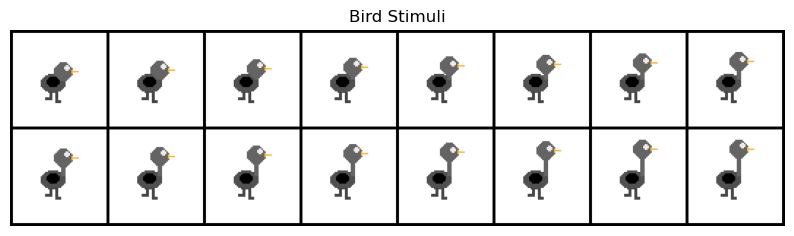

(1280, 2)


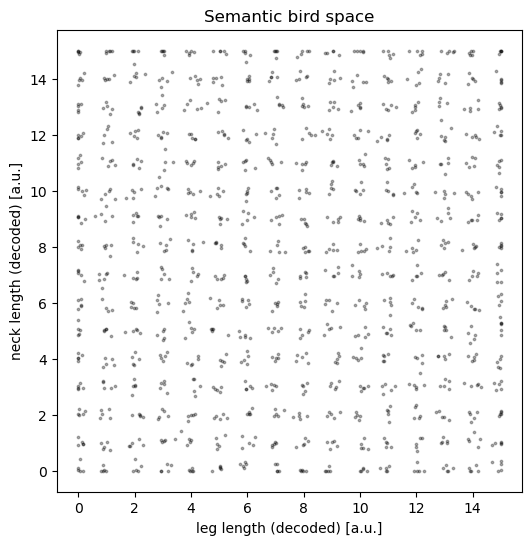

In [2]:
# Now we can use the grid cell machinery.

# if you get "torch" not resolved error, do "pip install torch" in the terminal for this python environmnet
# visual studio code let's you open a terminal in app

import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
from helper_fcts import check_dataset_range
from helper_fcts import load_GCs
from helper_fcts import find_anchors_and_target
from helper_fcts import valid_anchor_indices
from helper_fcts import find_anchors_for_given_target_v2
from helper_fcts import check_output_bounds
from helper_fcts import clip_vect_to_map
from helper_fcts import mean_overlap
from pin import pin
from prep_datasets import get_distances
from torchvision.utils import make_grid

# can use large or small number of birds
bird_images = torch.from_numpy(np.load("datasets/birds/bird_images.npy"))
#bird_images = torch.from_numpy(np.load("datasets/birds/bird_images_Nlarge.npy"))
show_images(bird_images[:16], "Bird Stimuli")

filename = f"datasets/birds/bird_linear_dec_all.npz"
#filename = f"datasets/birds/bird_linear_dec_all_Nlarge.npz"
tmp = np.load(filename)

leg_preds_np = tmp["leg_preds_np"]
neck_preds_np = tmp["neck_preds_np"] 
X_bird_np = tmp["X_np"]

data = np.transpose(np.array([leg_preds_np, neck_preds_np]))
data = data.astype(np.float32)
print(data.shape)


# add noise to both properties

sig_birds = 0.15
n_birds1  = np.random.normal(0, sig_birds, size=len(data))
n_birds0  = np.random.normal(0, sig_birds, size=len(data))
lim11     = np.min(data[:, 0])
lim12     = np.max(data[:, 0])
lim01     = np.min(data[:, 1])
lim02     = np.max(data[:, 1])
data[:,1] = data[:, 1] + n_birds1
data[:,0] = data[:, 0] + n_birds0
data[:,1] = np.clip(data[:,1], lim11, lim12)
data[:,0] = np.clip(data[:,0], lim01, lim02)

plt.figure(figsize=(6,6))
plt.scatter(data[:, 0], data[:, 1], s=3, c='black', alpha=0.3)
plt.xlabel("leg length (decoded) [a.u.]")
plt.ylabel("neck length (decoded) [a.u.]")
plt.title("Semantic bird space")
plt.show()

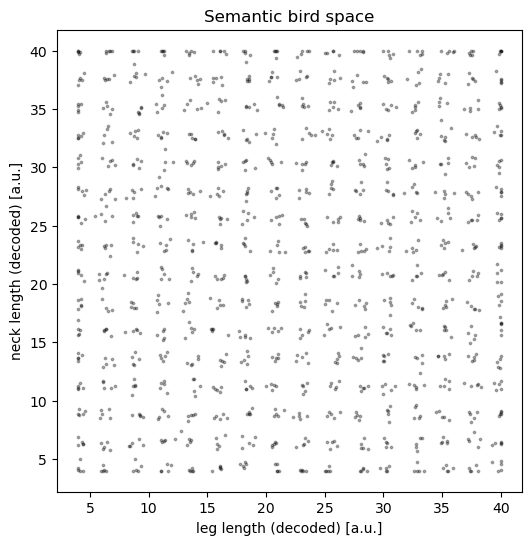

In [ ]:

GCs, res, N_GCs, N_mod, N_per_mod = load_GCs()

nec = data[:,0]
leg = data[:,1]
val = nec
aro = leg

val  = 4+(val-np.min(val))/(np.max(val)-np.min(val))*36
aro  = 4+(aro-np.min(aro))/(np.max(aro)-np.min(aro))*36
data = np.transpose(np.array([val,aro]))

eucl_data_dist, v_dist, a_dist = get_distances(data,val,aro)

dim1range, dim2range, prop, S1ind, S1coords, N_pts = check_dataset_range(data=data, dim1=val, dim2=aro, mapsize=res)

plt.figure(figsize=(6,6))
plt.scatter(data[:, 0], data[:, 1], s=3, c='black', alpha=0.3)
plt.xlabel("leg length (decoded) [a.u.]")
plt.ylabel("neck length (decoded) [a.u.]")
plt.title("Semantic bird space")
plt.show()

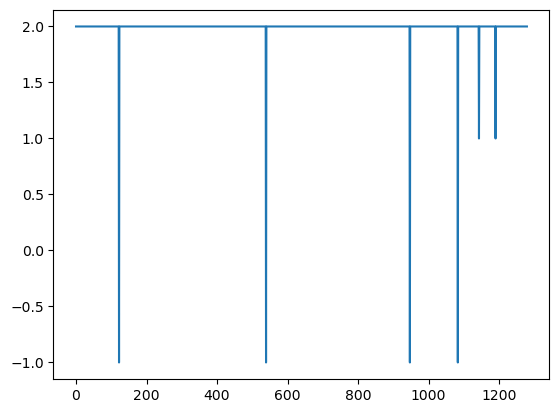

test counter 4


In [13]:
### FINAL - single trial, variable N 

# loaded dataset and grid cells above

# code is the same as for oasis, difference here is that the stimuli cluster

tolerance = 2

startPV      = GCs[22,22,:]   # no noise here
PVs          = np.zeros([N_pts, N_GCs])
PVs_xy       = np.zeros([N_pts,2])
PVs_xy_data  = np.zeros([N_pts,2]) # ground truth

PVs_xy[S1ind,0] = 22.  # like in main
PVs_xy[S1ind,1] = 22

PVs[S1ind,:] = startPV

Stims          = np.zeros([N_pts,2])
Stims[S1ind,0] = 10000 + S1ind 
Stims[S1ind,1] += 1

# place second stimulus with minimum distance
S1v        = val[S1ind]
S1a        = aro[S1ind]

x_offset = PVs_xy[S1ind,0]-S1v
y_offset = PVs_xy[S1ind,1]-S1a

PVs_xy_data[S1ind,:] = [val[S1ind]+x_offset,aro[S1ind]+y_offset]

S2ind      = np.random.randint(0, N_pts-1)  # first guess, check below
dist_S1_S2 = eucl_data_dist[S1ind,S2ind]
vect       = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]

while dist_S1_S2 < tolerance:   # check
    S2ind = np.random.randint(0, N_pts-1)
    vect = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]
    dist_S1_S2 = eucl_data_dist[S1ind,S2ind]

PVs_xy_data[S2ind,:] = [val[S2ind]+x_offset,aro[S2ind]+y_offset]

wts_mod = np.load("NAVwts/DCad2b_final.npz")
DCxpW = wts_mod["DCxp_2_tGCs_WTS"]
DCxmW = wts_mod["DCxm_2_tGCs_WTS"]
DCypW = wts_mod["DCyp_2_tGCs_WTS"]
DCymW = wts_mod["DCym_2_tGCs_WTS"]

vect_S1_S2 = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]
dist_S1_S2 = eucl_data_dist[S1ind,S2ind]

xy_tmp = pin(
    DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
    res=res, vect=vect_S1_S2, xc=22, yc=22, GCs=GCs)

nextPV          = GCs[xy_tmp[1],xy_tmp[0],:]
PVs[S2ind,:]    = nextPV
PVs_xy[S2ind,0] = xy_tmp[0]
PVs_xy[S2ind,1] = xy_tmp[1]
Stims[S2ind,0]  = 10000 + S2ind 
Stims[S2ind,1] += 1

### now let's infer the next grid cell PVs, here we apply noise and average

N = 1  
err_sig = 0
vote_tol = 2

###
configname = f"Noise{int(err_sig*10)}_ftol{tolerance}_N{N}"
###

test_cnt = 0

while np.any(Stims[:,0] == 0):

    anchors = valid_anchor_indices(Stims, PVs_xy)
    if anchors.size < 2:
        break

    (A1ind, A2ind, STind, vect_A1_T, dist_A1_T, vect_A2_T, dist_A2_T
        ) = find_anchors_and_target(Stims, eucl_data_dist, tolerance, v_dist, a_dist, PVs_xy)

    if A1ind is None or np.isnan(STind):
        break

    A1xc = int(PVs_xy[A1ind,0])  # coords on grid maps of Anchors - these are internal pointers
    A1yc = int(PVs_xy[A1ind,1])  # we always have anchors.  
    A2xc = int(PVs_xy[A2ind,0])
    A2yc = int(PVs_xy[A2ind,1])

    if not np.isnan(STind):
        
        PVs_xy_tmp1 = np.zeros([N,2])
        PVs_xy_tmp2 = np.zeros([N,2])
        
        vect_A1_T_safe = vect_A1_T
        vect_A2_T_safe = vect_A2_T

        ### inference time      
        xy_tmp1 = pin(
            DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
            res=res, vect=vect_A1_T_safe, xc=A1xc, yc=A1yc, GCs=GCs)
        #if check_output_bounds(xy_tmp1, GCs): xy_tmp1 = np.array([-1, -1]) 
        
        xy_tmp2 = pin(
            DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW, 
            res=res, vect=vect_A2_T_safe, xc=A2xc, yc=A2yc, GCs=GCs)
        #if check_output_bounds(xy_tmp2, GCs): xy_tmp2 = np.array([-1, -1])   
        
        # now track result - but in tmp
        PVs_xy_tmp1[0,0:2] = xy_tmp1  # 0:2 because of crazy python slicing, end doesn't count
        PVs_xy_tmp2[0,0:2] = xy_tmp2
        
        Stims[STind,0] = 10000 + STind # to avoid STing = 0 being an index and condition
        Stims[STind,1] = Stims[STind,1] + 1
        
    else: 
        break # no more target to be assigned
    
    
    for i in range(N-1):  # do N total with above, can always find anchors, even if we repeat them                                                                                                                                              
        
        (A1ind, A2ind, STind, vect_A1_T, dist_A1_T, vect_A2_T, dist_A2_T
            ) = find_anchors_for_given_target_v2(Stims, eucl_data_dist, tolerance, v_dist, a_dist, STind, PVs_xy)
        
        if A1ind is None:
            break

        A1xc = int(PVs_xy[A1ind,0])  # coords on grid maps of Anchors
        A1yc = int(PVs_xy[A1ind,1])  # we always have anchors.  
        A2xc = int(PVs_xy[A2ind,0])
        A2yc = int(PVs_xy[A2ind,1])

        vect_A1_T_safe = vect_A1_T
        vect_A2_T_safe = vect_A2_T
        
        ### inference time      
        xy_tmp1 = pin(
            DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
            res=res, vect=vect_A1_T_safe, xc=A1xc, yc=A1yc, GCs=GCs)
        #if check_output_bounds(xy_tmp1, GCs): xy_tmp1 = np.array([-1, -1]) 
        
        xy_tmp2 = pin(
            DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW, 
            res=res, vect=vect_A2_T_safe, xc=A2xc, yc=A2yc, GCs=GCs)
        #if check_output_bounds(xy_tmp2, GCs): xy_tmp2 = np.array([-1, -1]) 
        
        if np.any(np.isnan(xy_tmp1)) or np.any(np.isnan(xy_tmp2)):
            break
        
        PVs_xy_tmp1[i+1,0:2] = xy_tmp1
        PVs_xy_tmp2[i+1,0:2] = xy_tmp2

        Stims[STind,1] = Stims[STind,1] + 1
        #Stims[STind,0] = 10000 + STind 
        
    # vote
    coords, avgPVs, majority_vote = mean_overlap(PVs_xy_tmp1, PVs_xy_tmp2, vote_tol, GCs)

    newPV = GCs[coords[1],coords[0],:] 

    # now track result    
    if np.isnan(STind):
        break 
    
    PVs[STind,:]    = newPV 
    PVs_xy[STind,0] = coords[0]  
    PVs_xy[STind,1] = coords[1]
    Stims[STind,0]  = 10000 + STind          # to avoid STind = 0 being an index and condition    
    Stims[STind,1]  = Stims[STind,1] + 1
    
    PVs_xy_data[STind,:] = [val[STind]+x_offset,aro[STind]+y_offset]
    
    if majority_vote == 0:
        test_cnt += 1
        Stims[STind,1]  = -1  # no confidence in this one, number should trend down with N



plt.plot(Stims[:,1])
plt.show()

print('test counter', test_cnt)

# allow for more tolerance to show noise effect

#configname = f"Noise{int(err_sig*10)}_ftol2_N{N}}"
configname = f"Noise{int(0)}_ftol2_N{N}_post_decoder_data_noise"
#configname = f"Noise{int(0)}_ftol2_N{N}_post_decoder_data_noise_Nlarge"

filename1 = f"datasets/birds/{configname}_anchored_stimuli.npy"
filename2 = f"datasets/birds/{configname}_PVs.npy"
filename3 = f"datasets/birds/{configname}_PVcoordinates.npy"
filename33 = f"datasets/birds/{configname}_PVcoordinates_data.npy"
filename4 = f"datasets/birds/{configname}_datascatter.npy"

np.save(filename1, Stims)
np.save(filename2, PVs)
np.save(filename3, PVs_xy)
np.save(filename33, PVs_xy_data)
np.save(filename4, data)

# also show if we add noise to vec/dist, we can then re-triangulate, 
# noise can be around real mean, over time we converge on the real map?


configname Noise0_ftol2_N1_post_decoder_data_noise
[2.9 2.6 2.3 2.  1.7 1.4]


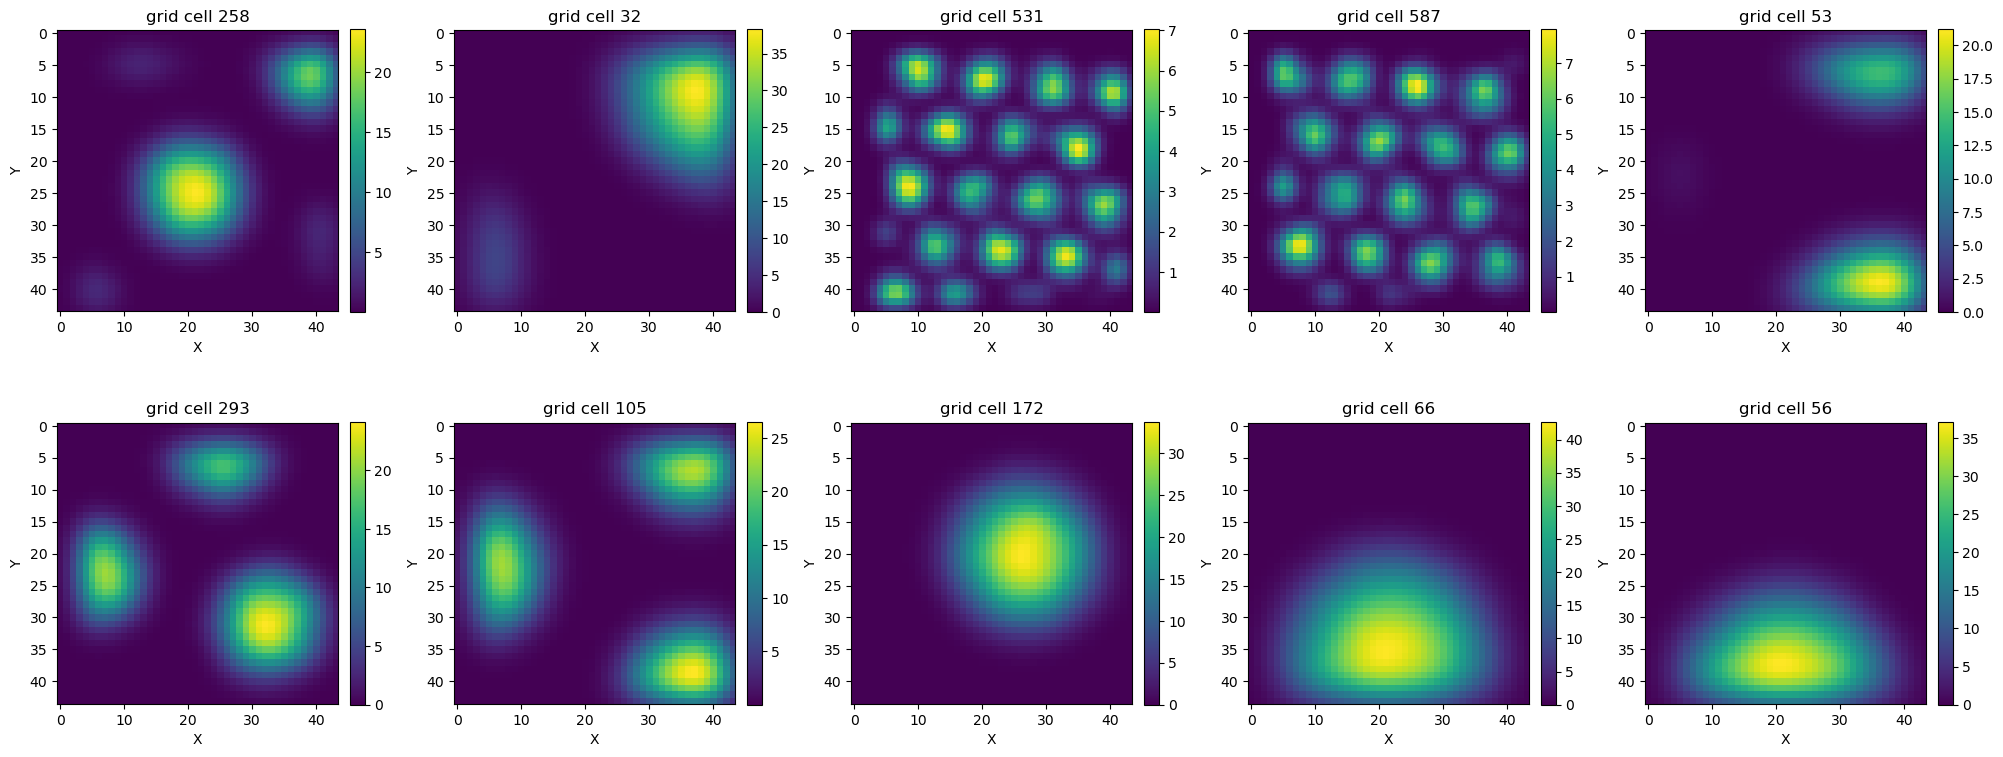

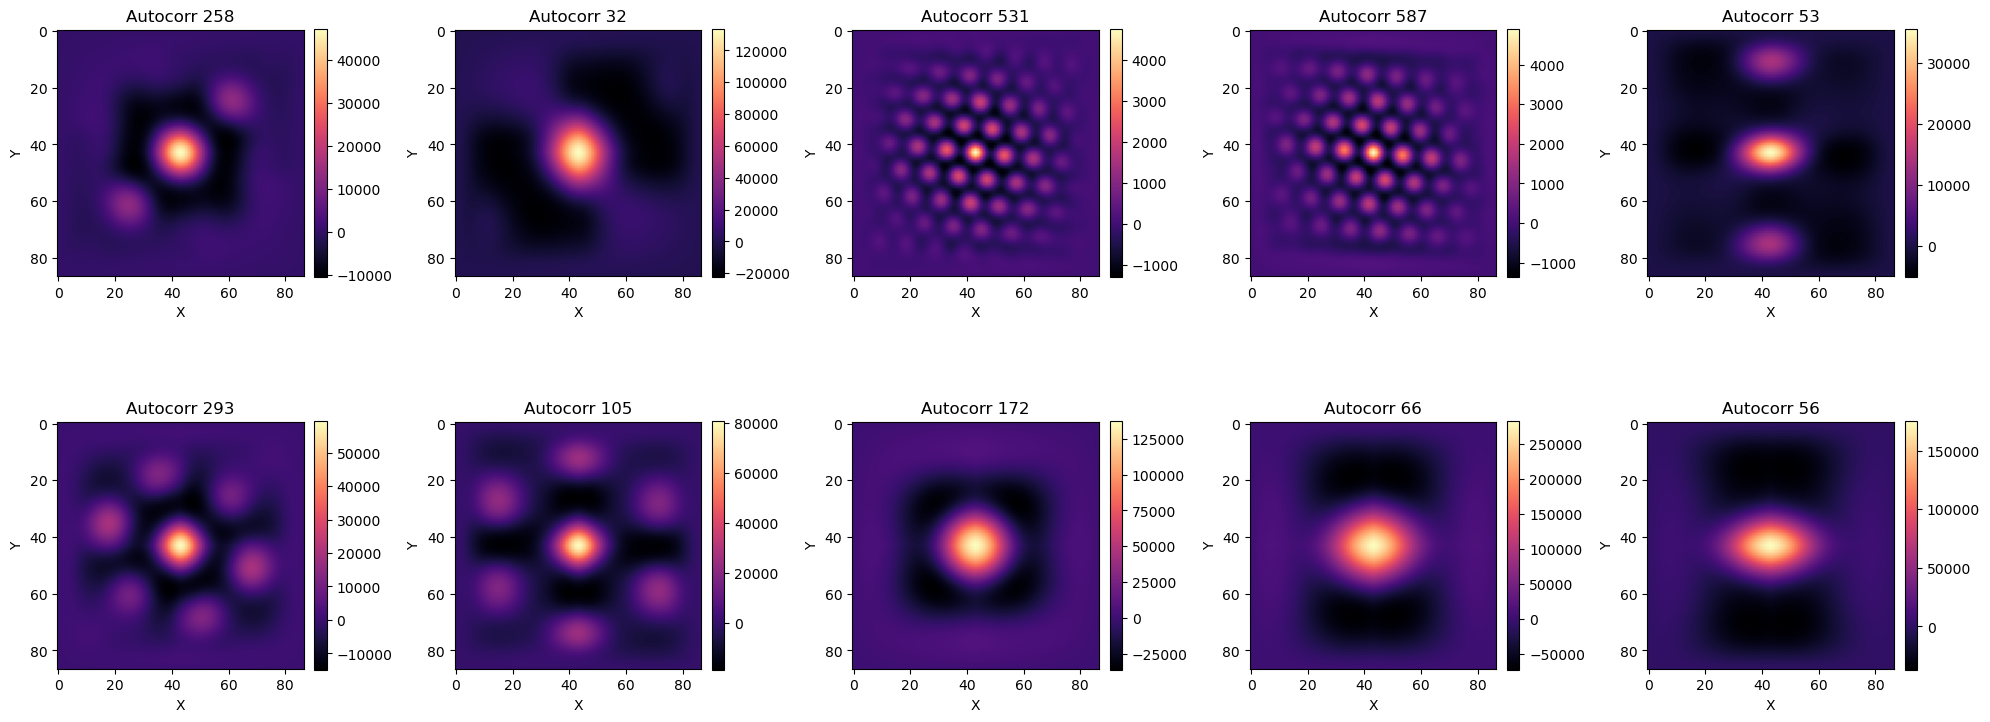

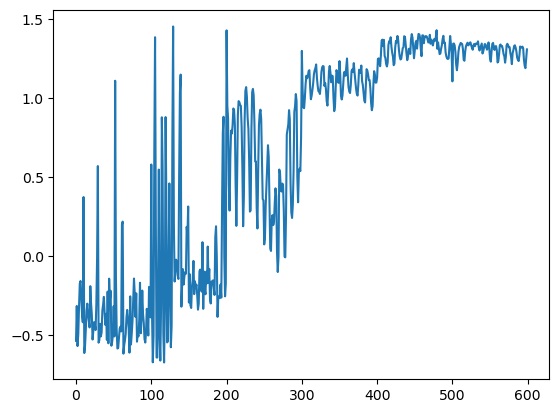

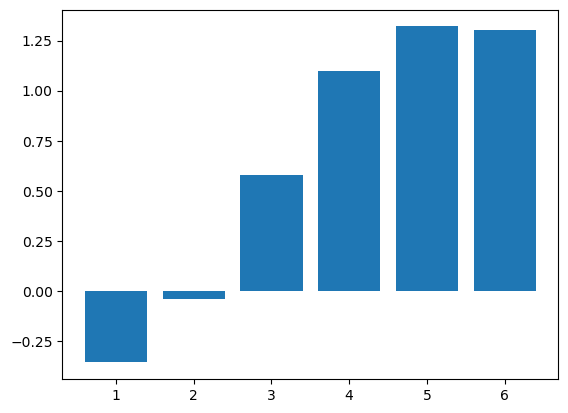

In [14]:
# inspect model output dataset 1 - Noise 1

import numpy as np
from inspect_data_grids import make_data_grids
from inspect_data_grids import plot_data_grids
from inspect_data_grids import plot_correlograms
from inspect_data_grids import plot_gridness
from grid_cells import AutoCorr
from grid_cells import Gridness
from helper_fcts import load_dataset_and_GCs

# Visualize grids

noise = 0
err_sig = 0
N = 1

#configname = f"Noise{int(err_sig*10)}_ftol2_N{N}"
configname = f"Noise{int(0)}_ftol2_N{N}_post_decoder_data_noise"
#configname = f"Noise{int(0)}_ftol2_N{N}_post_decoder_data_noise_Nlarge"
directory  = "datasets/birds/"

print("configname",configname)

Stims, PVs, PVs_xy, PVs_xy_data, GCs, res, N_GCs, N_mod, N_per_mod = load_dataset_and_GCs(configname,directory)

### even number please
N_plots = 10
cells2show = np.random.choice(np.arange(0, N_GCs-1), size=N_plots, replace=False)
###

cleanup = 0 # if we want to set small values to 0

sig = 1.5 # for Gauss HPC Kernel, 0.5 small, 1.5 big
#sigr = np.array([2.8, 2.2, 1.8, 1.7, 1.3, 0.9])*1 
sigr = np.array([2.9, 2.6, 2.3, 2.0, 1.7, 1.4])*1 

dataset_GCs = make_data_grids(N_GCs, res, Stims, PVs_xy_data, PVs, sig, sigr, cleanup)
plot_data_grids(dataset_GCs, N_plots, cells2show)

corr, x, y  = AutoCorr(dataset_GCs, N_GCs, res, h=1)
corr        = corr.data  # because this is a masked array
plot_correlograms(corr, N_plots, cells2show)

G           = Gridness(corr, x, y, N_GCs)
plot_gridness(G)

configname = f"Noise{int(err_sig*10)}_ftol2_N{N}"
savename   = f"datasets/birds/{configname}_G_Corr_dataGCs.npz"
np.savez(savename, corr=corr, x=x, y=y, G=G, dataset_GCs=dataset_GCs)



<function matplotlib.pyplot.show(close=None, block=None)>

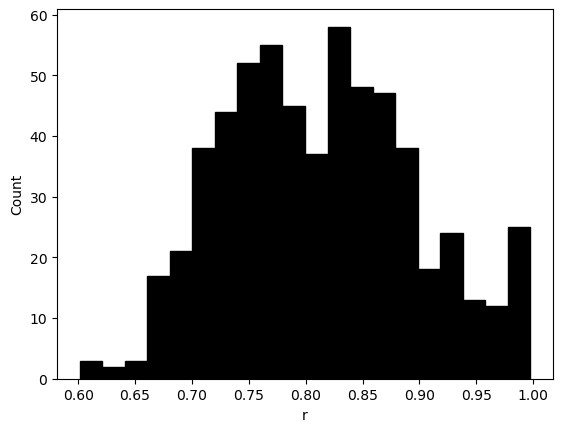

In [15]:
# correlate input and data grids

noise = 0

err_sig = 0
N = 1

#configname = f"Noise{int(err_sig*10)}_ftol2_N{N}"
configname = f"Noise{int(0)}_ftol2_N{N}_post_decoder_data_noise"
directory  = "datasets/birds/"

Stims, PVs, PVs_xy, PVs_xy_data, GCs, res, N_GCs, N_mod, N_per_mod = load_dataset_and_GCs(configname,directory)

tmp_out      = np.load("datasets/birds/Noise0_ftol2_N1_G_Corr_dataGCs.npz")
dataset_GCs  = tmp_out["dataset_GCs"]
G_out        = tmp_out["G"]

# for supp fig

from scipy.ndimage import shift as nd_shift

dx = np.median(PVs_xy[:,0] - PVs_xy_data[:,0])
dy = np.median(PVs_xy[:,1] - PVs_xy_data[:,1])
shift = np.array([int(np.round(dx)), int(np.round(dy))])

rec_shifted = np.zeros_like(dataset_GCs)

for i in range(N_GCs):
    rec_shifted[:,:,i] = nd_shift(dataset_GCs[:,:,i], shift=[dy, dx], mode='constant', cval=0)

# now corr for all cells, then hist
coeffi     = np.zeros([N_GCs,1])
for i in range(N_GCs):
    A = GCs[:,:,i]
    B = rec_shifted[:,:,i]
    r1 = np.corrcoef(A.flatten(), B.flatten())[0,1]
    coeffi[i]     = r1

filename = f"datasets/birds/Noise{int(0)}_ftol2_N{N}_corrcoef.npy"
np.save(filename, coeffi)

plt.hist(coeffi, 
    bins=20,
    alpha=1,          
    edgecolor='black',  
    color='black')    
#plt.title(f"r frequency - data vs input")
plt.xlabel("r")
plt.ylabel("Count")
plt.show
